# Experiment 02: Calculation of Co-channel Reuse Distance and Reuse Ratio

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 3 (frequency reuse, cluster/reuse geometry) and ICT-4203 Master Study Notes formulas used by the course.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To calculate the cluster size, co-channel reuse distance, and reuse ratio of a cellular system.

## Objectives

- Understand frequency reuse and co-channel cells.
- Generate valid hexagonal cluster sizes from shift parameters $(i,j)$.
- Calculate reuse distance $D$.
- Calculate reuse ratio $q=D/R$.
- Observe the capacity-versus-interference trade-off.

## Theory

**Frequency reuse** allows the same radio channels to be used in different cells that are separated by enough distance to keep co-channel interference within an acceptable level.

For the common hexagonal cellular model, a valid cluster size is

$$
N=i^2+ij+j^2
$$

where $i$ and $j$ are non-negative integers that describe the shift between co-channel cells.

If $R$ is the cell radius and $D$ is the distance between the centers of nearest co-channel cells, then

$$
D=R\sqrt{3N}
$$

The **co-channel reuse ratio** (also called the co-channel interference reduction factor in the course material) is

$$
q=\frac{D}{R}=\sqrt{3N}
$$

A larger $N$ gives a larger reuse distance and generally reduces co-channel interference, but the same spectrum is reused less frequently. A smaller $N$ improves capacity but requires stronger interference control.

## Procedure

1. Select cell radius $R$ and shift parameters $(i,j)$.
2. Calculate cluster size $N=i^2+ij+j^2$.
3. Calculate $q=\sqrt{3N}$.
4. Calculate $D=Rq$.
5. Repeat for several valid cluster sizes and compare the results graphically.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Configurable parameters
R_km = 1.0
i = 2
j = 1

N = i**2 + i*j + j**2
q = np.sqrt(3 * N)
D_km = R_km * q

print(f"Shift parameters (i, j) = ({i}, {j})")
print(f"Cluster size N          = {N}")
print(f"Cell radius R           = {R_km:.2f} km")
print(f"Reuse ratio q           = {q:.4f}")
print(f"Reuse distance D        = {D_km:.4f} km")

Shift parameters (i, j) = (2, 1)
Cluster size N          = 7
Cell radius R           = 1.00 km
Reuse ratio q           = 4.5826
Reuse distance D        = 4.5826 km


### Numerical Example

For $i=2$, $j=1$:

$$
N=2^2+(2)(1)+1^2=7
$$

Therefore,

$$
q=\sqrt{3(7)}=\sqrt{21}\approx4.583
$$

If $R=1$ km,

$$
D=1\times4.583\approx4.583\text{ km}
$$

### Visualization of the Cellular Frequency Reuse Pattern

In a regular hexagonal cellular geometry, the distance between the centers of any two adjacent cells sharing a common face is $\sqrt{3}R$, where $R$ is the cell radius. The cellular grid can be represented using two basis displacement vectors separated by an angle of $60^\circ$:

$$
\mathbf{u}_1 = (\sqrt{3}R,\, 0), \qquad \mathbf{u}_2 = \left(\frac{\sqrt{3}}{2}R,\, \frac{3}{2}R\right)
$$

To locate the nearest co-channel cells (cells reusing the identical set of frequency channels) for a cluster size $N$, the standard cellular engineering shift rule is:

1. Move $i$ cells along any chain of hexagons (along $\mathbf{u}_1$).
2. Turn $60^\circ$ counter-clockwise and move $j$ cells (along $\mathbf{u}_2$).

The resulting center-to-center displacement vector between the two co-channel cells is:

$$
\mathbf{D} = i\mathbf{u}_1 + j\mathbf{u}_2
$$

Evaluating the magnitude squared of this displacement via vector addition in the $60^\circ$ coordinate system yields:

$$
D^2 = \|\mathbf{D}\|^2 = (i\sqrt{3}R)^2 + (j\sqrt{3}R)^2 + 2(i\sqrt{3}R)(j\sqrt{3}R)\cos(60^\circ) = 3R^2(i^2 + j^2 + ij) = 3N R^2
$$

Thus, the theoretical co-channel reuse distance is:

$$
D = R\sqrt{3N}
$$

and the co-channel reuse ratio (interference reduction factor) is:

$$
q = \frac{D}{R} = \sqrt{3N}
$$

For $i = 2$, $j = 1$, and $R = 1.0\text{ km}$:

$$
N = 2^2 + (2)(1) + 1^2 = 7, \qquad q = \sqrt{21} \approx 4.5826, \qquad D = 1.0 \times \sqrt{21} \approx 4.5826\text{ km}
$$

In a cluster of size $N = 7$, the available radio spectrum is divided into seven disjoint frequency groups, denoted $F_1, F_2, \dots, F_7$. Below, we visualize this frequency-reuse pattern on a hexagonal grid, highlighting the reference cell $(0, 0)$ and its nearest co-channel neighbor $(2, 1)$, both allocated frequency group $F_1$.

Cluster size N                  = 7
Cell radius R                   = 1.00 km
Reuse ratio q                   = 4.5826
Co-channel reuse distance D     = 4.5826 km
Distance between cell centers   = 4.5826 km
Numerical verification (dist==D): True


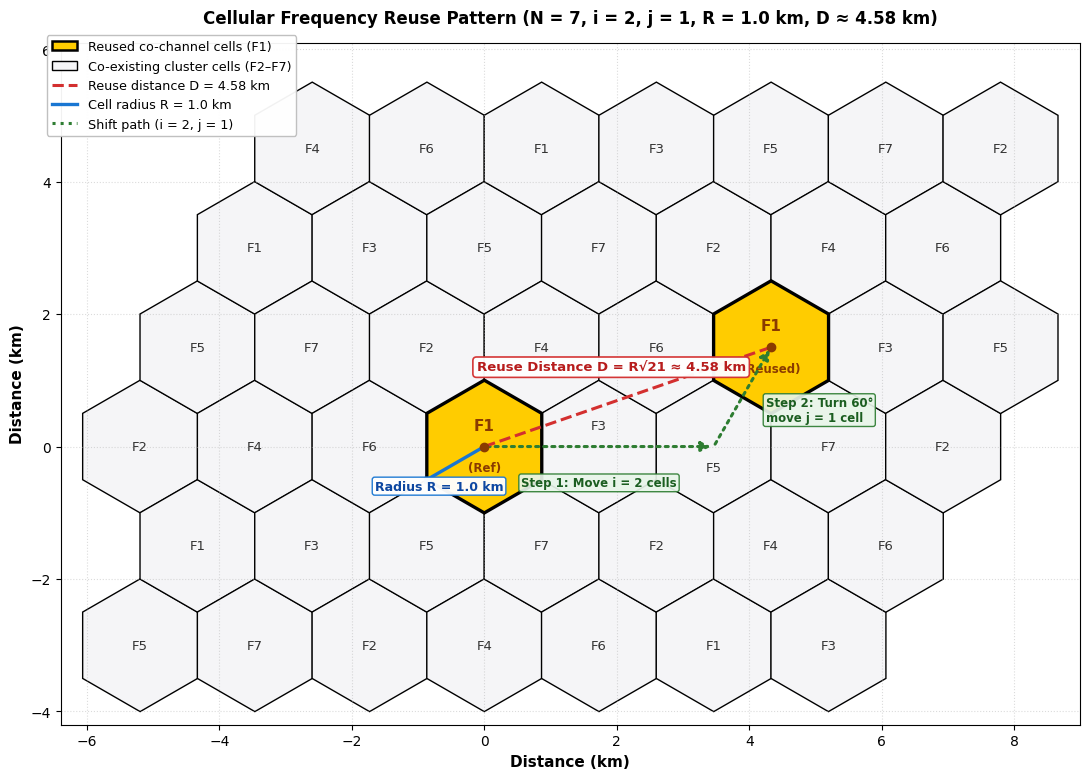

In [2]:
from matplotlib.patches import Polygon, Patch
from matplotlib.lines import Line2D

# Configurable parameters for frequency reuse visualization
R_reuse_km = 1.0
R_draw_km = R_reuse_km * 1.002  # drawing overlap to eliminate raster hairlines
i_shift = 2
j_shift = 1

N_reuse = i_shift**2 + i_shift * j_shift + j_shift**2
q_reuse = np.sqrt(3 * N_reuse)
D_reuse_km = R_reuse_km * q_reuse

# Pointy-top hexagon vertex angles (points at top and bottom: 30°, 90°, 150°, 210°, 270°, 330°)
angles = np.array([30, 90, 150, 210, 270, 330]) * np.pi / 180.0

def get_hexagon_vertices(center, radius):
    """Return 6x2 array of vertices for a pointy-top hexagon centered at center."""
    x = center[0] + radius * np.cos(angles)
    y = center[1] + radius * np.sin(angles)
    return np.column_stack([x, y])

# Basis vectors for pointy-top hexagon centers (adjacent center distance = sqrt(3)*R)
d_step = np.sqrt(3) * R_reuse_km
u1 = np.array([d_step, 0.0])
u2 = np.array([d_step * 0.5, d_step * np.sqrt(3) / 2.0])

# Coordinates of reference cell (0, 0) and nearest co-channel cell (i, j)
ref_idx = (0, 0)
target_idx = (i_shift, j_shift)
c_ref = ref_idx[0] * u1 + ref_idx[1] * u2
c_target = target_idx[0] * u1 + target_idx[1] * u2

# Numerically calculate Euclidean distance between the two cell centers
center_distance_km = np.linalg.norm(c_target - c_ref)
distance_verified = np.isclose(center_distance_km, D_reuse_km)

# Print values before displaying the figure
print(f"Cluster size N                  = {N_reuse}")
print(f"Cell radius R                   = {R_reuse_km:.2f} km")
print(f"Reuse ratio q                   = {q_reuse:.4f}")
print(f"Co-channel reuse distance D     = {D_reuse_km:.4f} km")
print(f"Distance between cell centers   = {center_distance_km:.4f} km")
print(f"Numerical verification (dist==D): {distance_verified}")

# Construct hexagonal grid cells with frequency group assignment F1..F7
cells_to_draw = []
for u in range(-3, 5):
    for v in range(-2, 4):
        pos = u * u1 + v * u2
        if -5.5 <= pos[0] <= 8.5 and -4.0 <= pos[1] <= 5.0:
            freq = ((2 * u + 3 * v) % 7) + 1
            cells_to_draw.append((u, v, pos, freq))

fig, ax = plt.subplots(figsize=(11, 8.5))

# Draw each cell using Polygon with manually computed vertices
for u, v, pos, freq in cells_to_draw:
    is_ref = (u == ref_idx[0] and v == ref_idx[1])
    is_target = (u == target_idx[0] and v == target_idx[1])
    is_highlighted = is_ref or is_target

    verts = get_hexagon_vertices(pos, R_draw_km)
    facecolor = '#FFCC00' if is_highlighted else '#F5F5F7'
    edgecolor = 'black'
    linewidth = 2.4 if is_highlighted else 1.0

    poly = Polygon(
        verts, closed=True,
        facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth,
        zorder=2 if is_highlighted else 1
    )
    ax.add_patch(poly)

    # Label cells
    if is_ref:
        ax.text(pos[0], pos[1] + 0.32, "F1", ha='center', va='center',
                fontsize=11, fontweight='bold', color='#8A3B00', zorder=4)
        ax.text(pos[0], pos[1] - 0.32, "(Ref)", ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='#8A3B00', zorder=4)
    elif is_target:
        ax.text(pos[0], pos[1] + 0.32, "F1", ha='center', va='center',
                fontsize=11, fontweight='bold', color='#8A3B00', zorder=4)
        ax.text(pos[0], pos[1] - 0.32, "(Reused)", ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='#8A3B00', zorder=4)
    elif (u, v) == (1, 0):
        ax.text(pos[0], pos[1] + 0.32, f"F{freq}", ha='center', va='center',
                fontsize=9.5, color='#333333', zorder=3)
    elif (u, v) == (2, 0):
        ax.text(pos[0], pos[1] - 0.32, f"F{freq}", ha='center', va='center',
                fontsize=9.5, color='#333333', zorder=3)
    else:
        ax.text(pos[0], pos[1], f"F{freq}", ha='center', va='center',
                fontsize=9.5, color='#333333', zorder=3)

# Highlight cell centers
ax.plot(c_ref[0], c_ref[1], 'o', color='#8A3B00', markersize=6, zorder=6)
ax.plot(c_target[0], c_target[1], 'o', color='#8A3B00', markersize=6, zorder=6)

# 1. Co-channel reuse distance D line
ax.plot([c_ref[0], c_target[0]], [c_ref[1], c_target[1]],
        color='#D32F2F', linestyle='--', linewidth=2.2, zorder=5)

mid_D = (c_ref + c_target) / 2.0
ax.text(
    mid_D[0] - 0.25, mid_D[1] + 0.35,
    f"Reuse Distance D = R√21 ≈ {D_reuse_km:.2f} km",
    fontsize=9.5, fontweight='bold', color='#B71C1C',
    ha='center', va='bottom',
    bbox=dict(boxstyle='round,pad=0.28', facecolor='#FFFFFF', edgecolor='#D32F2F', linewidth=1.2, alpha=0.96),
    zorder=7
)

# 2. Cell radius R line in reference cell (center to bottom-left vertex)
v_bl = c_ref + np.array([-np.sqrt(3) / 2.0 * R_reuse_km, -0.5 * R_reuse_km])
ax.plot([c_ref[0], v_bl[0]], [c_ref[1], v_bl[1]],
        color='#1976D2', linestyle='-', linewidth=2.4, zorder=5)
ax.plot(v_bl[0], v_bl[1], 's', color='#1976D2', markersize=4, zorder=6)
mid_R = (c_ref + v_bl) / 2.0
ax.text(
    mid_R[0] - 0.25, mid_R[1] - 0.25,
    f"Radius R = {R_reuse_km:.1f} km",
    fontsize=9, fontweight='bold', color='#0D47A1',
    ha='center', va='top',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFFFFF', edgecolor='#1976D2', linewidth=1.0, alpha=0.96),
    zorder=7
)

# 3. Shift trajectory (i = 2, j = 1)
step_i_end = c_ref + i_shift * u1
ax.annotate("", xy=step_i_end, xytext=c_ref,
            arrowprops=dict(arrowstyle="-|>", color='#2E7D32', linestyle=':', lw=2.2, mutation_scale=14),
            zorder=4)
ax.annotate("", xy=c_target, xytext=step_i_end,
            arrowprops=dict(arrowstyle="-|>", color='#2E7D32', linestyle=':', lw=2.2, mutation_scale=14),
            zorder=4)

ax.text(step_i_end[0] / 2.0, step_i_end[1] - 0.45, f"Step 1: Move i = {i_shift} cells",
        ha='center', va='top', fontsize=8.5, color='#1B5E20', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#E8F5E9', edgecolor='#2E7D32', alpha=0.92),
        zorder=6)

mid_j = (step_i_end + c_target) / 2.0
ax.text(mid_j[0] + 0.35, mid_j[1] - 0.2, f"Step 2: Turn 60°\nmove j = {j_shift} cell",
        ha='left', va='center', fontsize=8.5, color='#1B5E20', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#E8F5E9', edgecolor='#2E7D32', alpha=0.92),
        zorder=6)

# Labels, title, grid, equal aspect ratio
ax.set_xlabel("Distance (km)", fontsize=11, fontweight='semibold')
ax.set_ylabel("Distance (km)", fontsize=11, fontweight='semibold')
ax.set_title(
    f"Cellular Frequency Reuse Pattern (N = {N_reuse}, i = {i_shift}, j = {j_shift}, R = {R_reuse_km:.1f} km, D ≈ {D_reuse_km:.2f} km)",
    fontsize=12, fontweight='bold', pad=14
)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.45)

# Clear legend
legend_elements = [
    Patch(facecolor='#FFCC00', edgecolor='black', linewidth=1.8, label='Reused co-channel cells (F1)'),
    Patch(facecolor='#F5F5F7', edgecolor='black', linewidth=1.0, label='Co-existing cluster cells (F2–F7)'),
    Line2D([0], [0], color='#D32F2F', linestyle='--', linewidth=2.2, label=f'Reuse distance D = {D_reuse_km:.2f} km'),
    Line2D([0], [0], color='#1976D2', linestyle='-', linewidth=2.4, label=f'Cell radius R = {R_reuse_km:.1f} km'),
    Line2D([0], [0], color='#2E7D32', linestyle=':', linewidth=2.2, label=f'Shift path (i = {i_shift}, j = {j_shift})'),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(-0.02, 1.02),
          framealpha=0.95, edgecolor='#BDBDBD', fontsize=9.2)

all_x = [p[0] for _, _, p, _ in cells_to_draw]
all_y = [p[1] for _, _, p, _ in cells_to_draw]
ax.set_xlim(min(all_x) - 1.2, max(all_x) + 1.2)
ax.set_ylim(min(all_y) - 1.2, max(all_y) + 1.6)

plt.tight_layout()
plt.show()

**Observation:** The spatial layout illustrates the fundamental cellular engineering trade-off between network capacity and co-channel interference:

1. **Interference reduction with larger cluster size:** By separating co-channel $F_1$ cells by a distance $D = R\sqrt{3N} \approx 4.58\text{ km}$ (a reuse ratio $q = \sqrt{21} \approx 4.583$), propagation attenuation keeps co-channel interference ($CCI$) sufficiently low, achieving an acceptable signal-to-interference ratio ($S/I$). Increasing $N$ places co-channel base stations farther apart, lowering co-channel interference and improving link quality.
2. **Capacity cost of large clusters:** However, because the total frequency spectrum must be partitioned among $N$ distinct cell groups, each individual cell receives only $1/N$ of the available channels. A larger cluster size therefore reduces the traffic channel capacity per cell.
3. **Capacity benefit of smaller clusters:** Conversely, a smaller cluster size (such as $N = 4$ or $N = 3$) allocates more channels to each cell, increasing overall spectral efficiency and subscriber capacity per square kilometer. The trade-off is a reduced co-channel reuse distance $D$, which increases interference and requires tighter interference management (e.g., cell sectoring or power control).

In [3]:
# Generate valid cluster sizes for small i and j
valid = set()
for ii in range(0, 5):
    for jj in range(0, 5):
        if ii == 0 and jj == 0:
            continue
        valid.add(ii**2 + ii*jj + jj**2)

valid_cluster_sizes = np.array(sorted(valid))
reuse_ratios = np.sqrt(3 * valid_cluster_sizes)
reuse_distances = R_km * reuse_ratios

print("Some valid cluster sizes:", valid_cluster_sizes.tolist())

Some valid cluster sizes: [1, 3, 4, 7, 9, 12, 13, 16, 19, 21, 27, 28, 37, 48]


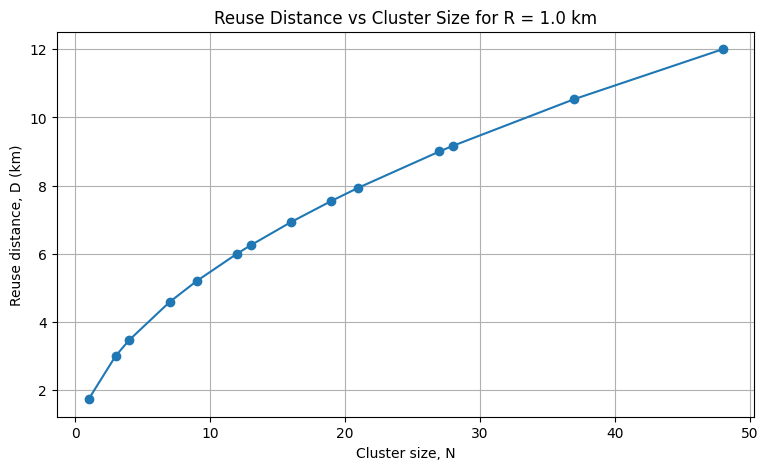

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(valid_cluster_sizes, reuse_distances, marker="o")
plt.xlabel("Cluster size, N")
plt.ylabel("Reuse distance, D (km)")
plt.title(f"Reuse Distance vs Cluster Size for R = {R_km:.1f} km")
plt.grid(True)
plt.show()

**Observation:** Reuse distance increases with cluster size. Thus co-channel cells are placed farther apart when a larger cluster is used.

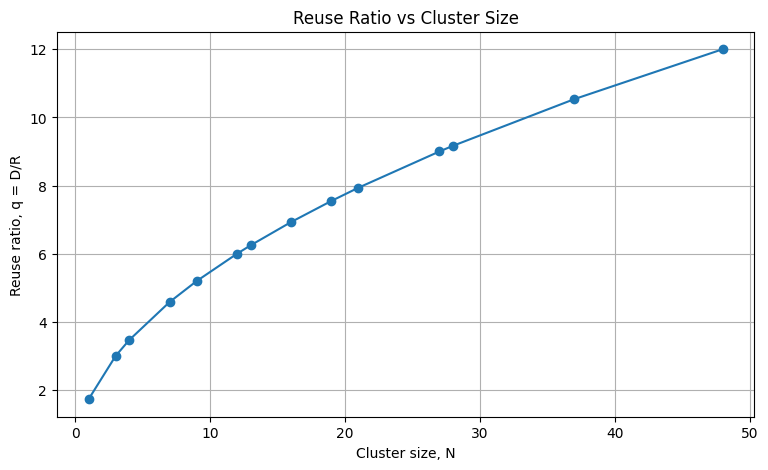

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(valid_cluster_sizes, reuse_ratios, marker="o")
plt.xlabel("Cluster size, N")
plt.ylabel("Reuse ratio, q = D/R")
plt.title("Reuse Ratio vs Cluster Size")
plt.grid(True)
plt.show()

## Result and Discussion

For the example $N=7$ and $R=1$ km, the reuse ratio is approximately **4.583** and the nearest co-channel reuse distance is approximately **4.583 km**. Increasing $N$ increases both $q$ and $D$, which improves co-channel separation but reduces how frequently a channel set can be reused.

## Conclusion

The standard hexagonal frequency-reuse equations were implemented successfully and the relation between cluster size, reuse ratio, and co-channel distance was verified.

## Viva Questions and Short Answers

1. **What is frequency reuse?**  
   Reusing the same channel set in geographically separated cells.

2. **What are co-channel cells?**  
   Cells that use the same radio frequencies.

3. **What is the reuse ratio?**  
   $q=D/R$.

4. **Why does a larger cluster reduce interference?**  
   It increases the separation between co-channel cells.

5. **What is the trade-off of increasing $N$?**  
   Lower co-channel interference but less frequent spectrum reuse and lower capacity.